# Heart Disease Classification using Decision Trees and Random Forests

**Name(s) and Registration Number(s):**
- [Benson Kamau] — [S084-01-1967/2023]
- [James Ndungu] — [S084-01-1968/2023]

**Date:** 28 July 2026

**Dataset:** UCI Heart Disease Dataset (`heart.csv`)

--


## 1. Import the Required Libraries

Before any analysis can begin, we need to import the Python libraries that provide the tools for data handling, visualization, and machine learning.

### Purpose of the Imported Libraries

- **pandas (pd):** Used for loading, organizing, and manipulating datasets.
- **numpy (np):** Provides support for numerical computations and mathematical operations.
- **matplotlib.pyplot (plt):** Used for creating graphs and visualizations.
- **seaborn (sns):** Used to create attractive statistical graphics.
- **train_test_split:** Splits the dataset into training and testing sets.
- **DecisionTreeClassifier:** Builds a Decision Tree classification model.
- **RandomForestClassifier:** Builds a Random Forest classification model.
- **OneHotEncoder:** Converts categorical variables into numerical format using one-hot encoding.
- **accuracy_score:** Calculates the classification accuracy.
- **classification_report:** Displays precision, recall, F1-score, and support.
- **confusion_matrix:** Summarizes prediction results.
- **ConfusionMatrixDisplay:** Displays the confusion matrix graphically.
- **warnings:** Suppresses unnecessary warning messages to keep the notebook output clean.

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Splitting the dataset
from sklearn.model_selection import train_test_split,GridSearchCV

# Machine Learning Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# One-Hot Encoding
from sklearn.preprocessing import OneHotEncoder

# Model evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
precision_score,
    recall_score,
    f1_score,
    ConfusionMatrixDisplay
)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")


# 2. Import the Dataset

In this section, the Heart Disease dataset is imported into Python using the Pandas library. After loading the dataset, the first a records are displayed to verify that the dataset has been loaded correctly.

In [2]:
df = pd.read_csv("heart.csv")
df.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


The `head()` function displays the first five rows of the dataset. This helps verify that the dataset has been imported correctly and provides an initial understanding of the variables contained in the dataset.

## 3. Examine the Dataset Structure

Before preprocessing, we examine the shape, data types, summary statistics, and target distribution of the dataset to understand what we are working with.


### 3.1 Determine the Shape of the Dataset

The shape of the dataset indicates the number of observations (rows) and variables (columns).

In [3]:

# Display the number of rows and columns
df.shape

(303, 14)

### 3.2 Display the Column Names

The column names identify all the variables contained in the dataset.

In [4]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='str')

### 3.3 Examine the Data Types

The data type of each variable determines whether it is numerical or categorical. This information is useful during data preprocessing and feature encoding.

In [5]:
df.dtypes

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

### 3.4 General Information about the Dataset

The `info()` function provides a summary of the dataset, including the number of observations, column names, data types, and the number of non-missing values.

In [6]:
# Data types and non-null counts
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


### 3.5 Summary Statistics

Summary statistics provide important descriptive measures such as the mean, standard deviation, minimum, maximum, and quartiles for the numerical variables in the dataset.

In [7]:
# Summary statistics for numerical columns
df.describe()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


target
1    165
0    138
Name: count, dtype: int64


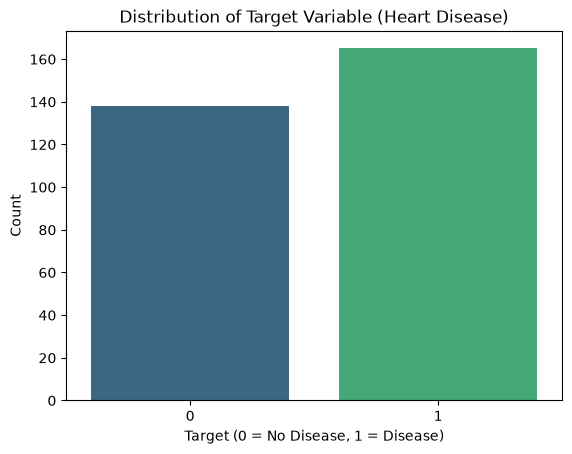

In [8]:
# Distribution of the target variable
print(df["target"].value_counts())

sns.countplot(x="target", data=df, hue="target", palette="viridis", legend=False)
plt.title("Distribution of Target Variable (Heart Disease)")
plt.xlabel("Target (0 = No Disease, 1 = Disease)")
plt.ylabel("Count")
plt.show()


## 4. Preprocess the Data

We check the dataset for duplicate rows and missing values, and handle any issues found before moving to model building.


## 4.3 Check for Missing Values

Missing values can reduce the quality of a machine learning model. It is therefore important to determine whether any variables contain missing observations.

In [9]:
# Check for missing values
print(df.isnull().sum())


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


The `isnull()` function identifies missing values in each column, while the `sum()` function counts the total number of missing values for every variable.

## 4.1 Check for Duplicate Records

Duplicate records can negatively affect the performance of machine learning models. Therefore, it is important to identify whether duplicate observations exist in the dataset.

In [10]:
# Check for duplicate records
duplicates = df.duplicated().sum()

print("Number of duplicate records:", duplicates)

Number of duplicate records: 1


## 4.2 Remove Duplicate Records

If duplicate records are found, they should be removed to prevent bias during model training.

In [11]:

# Remove duplicate records
df = df.drop_duplicates()

# Display the new shape of the dataset
print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (302, 14)


The `drop_duplicates()` function removes all duplicate rows from the dataset while retaining only unique observations.

## 5. Data Preparation for Machine Learning

With a clean dataset, we now prepare it for model training: separating predictors from the target, identifying feature types, encoding categorical variables, and splitting into training and testing sets.


### 5.1 Separate Predictors and Target

`X` holds the predictor (feature) columns, while `y` holds the target column we want to predict (`target`: presence of heart disease).


In [12]:
X = df.drop(columns=["target"])
y = df["target"]

print(f"Predictors shape: {X.shape}")
print(f"Target shape: {y.shape}")


Predictors shape: (302, 13)
Target shape: (302,)


### 5.2 Identify Numerical and Categorical Features

Although every column in this dataset is stored numerically, several columns are actually **categorical/coded** variables (e.g., `cp` = chest pain type, `thal` = thalassemia result). We identify these based on the dataset's data dictionary so that they can be one-hot encoded appropriately, while genuinely continuous measurements are kept as numerical features.


In [13]:
categorical_features = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]
numerical_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]

print("Categorical features:", categorical_features)
print("Numerical features:", numerical_features)

# Sanity check: every predictor column should be accounted for
assert set(categorical_features + numerical_features) == set(X.columns)


Categorical features: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
Numerical features: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']


Numerical features contain continuous or discrete numerical values, whereas categorical features contain text or categories. Identifying these feature types helps determine the appropriate preprocessing method.

### 5.3 Encode Categorical Variables

We use **one-hot encoding** (`pd.get_dummies`) to convert the categorical features into binary indicator columns. `drop_first=True` is used to avoid the "dummy variable trap" (perfect multicollinearity) by dropping one category per feature as the reference level.


In [14]:
X_encoded = pd.get_dummies(X, columns=categorical_features, drop_first=True)

print(f"Shape before encoding: {X.shape}")
print(f"Shape after encoding: {X_encoded.shape}")
X_encoded.head()


Shape before encoding: (302, 13)
Shape after encoding: (302, 22)


,age,trestbps,chol,thalach,oldpeak,sex_1,cp_1,cp_2,cp_3,fbs_1,...,exang_1,slope_1,slope_2,ca_1,ca_2,ca_3,ca_4,thal_1,thal_2,thal_3
0,63,145,233,150,2.3,True,False,False,True,True,...,False,False,False,False,False,False,False,True,False,False
1,37,130,250,187,3.5,True,False,True,False,False,...,False,False,False,False,False,False,False,False,True,False
2,41,130,204,172,1.4,False,True,False,False,False,...,False,False,True,False,False,False,False,False,True,False
3,56,120,236,178,0.8,True,True,False,False,False,...,False,False,True,False,False,False,False,False,True,False
4,57,120,354,163,0.6,False,False,False,False,False,...,True,False,True,False,False,False,False,False,True,False


### 5.4 Divide the Dataset into Training and Testing Sets

We split the data into training (80%) and testing (20%) sets. `stratify=y` ensures both sets preserve the same proportion of disease/no-disease cases as the original dataset, and `random_state` ensures the split is reproducible.


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")
print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))
print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))


Training set: 241 samples
Testing set: 61 samples

Training target distribution:
target
1    0.543568
0    0.456432
Name: proportion, dtype: float64

Testing target distribution:
target
1    0.540984
0    0.459016
Name: proportion, dtype: float64


The dataset has been successfully divided into training and testing sets. The training data will be used to build the machine learning models, while the testing data will be used to evaluate their predictive performance.

## 6. Decision Tree Model

We now build Decision Tree classifiers, starting with an unrestricted (fully-grown) tree, then examining its size and complexity, and finally training a controlled (pruned) tree to reduce overfitting.


### 6.1 Train an Unrestricted Decision Tree

An unrestricted tree is allowed to grow until every leaf is pure (or contains too few samples to split), which typically leads to a very complex tree that overfits the training data.


In [16]:
dt_unrestricted = DecisionTreeClassifier(random_state=42)
dt_unrestricted.fit(X_train, y_train)

y_train_pred_unrestricted = dt_unrestricted.predict(X_train)
y_test_pred_unrestricted = dt_unrestricted.predict(X_test)

train_acc = accuracy_score(y_train, y_train_pred_unrestricted)
test_acc = accuracy_score(y_test, y_test_pred_unrestricted)

print(f"Unrestricted Decision Tree — Training Accuracy: {train_acc:.4f}")
print(f"Unrestricted Decision Tree — Testing Accuracy:  {test_acc:.4f}")
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred_unrestricted))


Unrestricted Decision Tree — Training Accuracy: 1.0000
Unrestricted Decision Tree — Testing Accuracy:  0.7705

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.79      0.68      0.73        28
           1       0.76      0.85      0.80        33

    accuracy                           0.77        61
   macro avg       0.77      0.76      0.77        61
weighted avg       0.77      0.77      0.77        61



### 6.2 Examine the Size of the Tree

We inspect the depth and number of leaves of the unrestricted tree. A large depth/leaf count relative to the number of training samples is a strong indicator of overfitting — the gap between training and testing accuracy above confirms this.


In [17]:
depth = dt_unrestricted.get_depth()
n_leaves = dt_unrestricted.get_n_leaves()
n_nodes=dt_unrestricted.tree_.node_count
print("Number of Nodes:", n_nodes)

print(f"Tree depth: {depth}")
print(f"Number of leaves: {n_leaves}")
print(f"Number of training samples: {X_train.shape[0]}")

overfit_gap = train_acc - test_acc
print(f"\nTrain-Test accuracy gap: {overfit_gap:.4f} "
      f"({'signs of overfitting' if overfit_gap > 0.05 else 'reasonable generalization'})")


Number of Nodes: 83
Tree depth: 9
Number of leaves: 42
Number of training samples: 241

Train-Test accuracy gap: 0.2295 (signs of overfitting)


A deeper tree with many nodes can capture complex relationships in the data, but it may also memorize the training data instead of learning general patterns.

### 6.3 Train a Controlled Decision Tree

To reduce overfitting, we constrain the tree's growth using hyperparameters such as `max_depth` and `min_samples_leaf`. We use `GridSearchCV` with cross-validation to search for good hyperparameter values, then compare the resulting tree's performance and size against the unrestricted tree.


In [18]:
param_grid = {
    "max_depth": [2, 3, 4, 5, 6, 7, 8],
    "min_samples_leaf": [1, 2, 5, 10, 15]
}

grid_search_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)
grid_search_dt.fit(X_train, y_train)

print(f"Best parameters: {grid_search_dt.best_params_}")
print(f"Best cross-validation accuracy: {grid_search_dt.best_score_:.4f}")

dt_controlled = grid_search_dt.best_estimator_


Best parameters: {'max_depth': 4, 'min_samples_leaf': 1}
Best cross-validation accuracy: 0.7721


In [19]:
y_train_pred_controlled = dt_controlled.predict(X_train)
y_test_pred_controlled = dt_controlled.predict(X_test)

train_acc_ctrl = accuracy_score(y_train, y_train_pred_controlled)
test_acc_ctrl = accuracy_score(y_test, y_test_pred_controlled)

print(f"Controlled Decision Tree — Depth: {dt_controlled.get_depth()}, Leaves: {dt_controlled.get_n_leaves()}")
print(f"Controlled Decision Tree — Training Accuracy: {train_acc_ctrl:.4f}")
print(f"Controlled Decision Tree — Testing Accuracy:  {test_acc_ctrl:.4f}")
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred_controlled))


Controlled Decision Tree — Depth: 4, Leaves: 16
Controlled Decision Tree — Training Accuracy: 0.9046
Controlled Decision Tree — Testing Accuracy:  0.7213

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.72      0.64      0.68        28
           1       0.72      0.79      0.75        33

    accuracy                           0.72        61
   macro avg       0.72      0.72      0.72        61
weighted avg       0.72      0.72      0.72        61



The controlled Decision Tree is expected to have a smaller depth and fewer nodes than the unrestricted tree. This reduction in complexity helps minimize overfitting while maintaining good predictive performance.

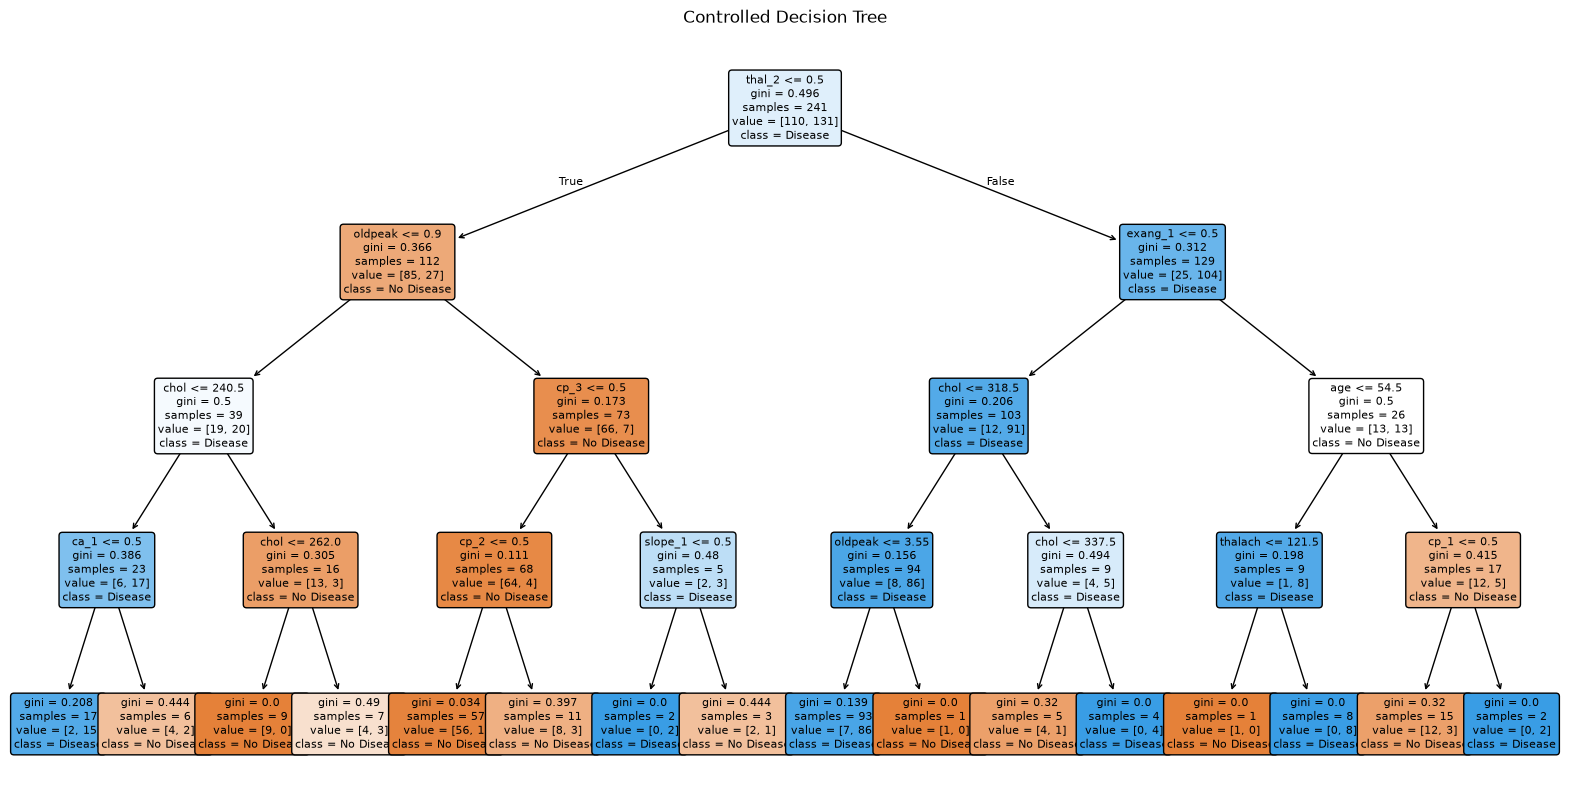

In [20]:
# Visualize the controlled (pruned) decision tre
from sklearn.tree import plot_tree
plt.figure(figsize=(20, 10))
plot_tree(
    dt_controlled,
    feature_names=X_encoded.columns,
    class_names=["No Disease", "Disease"],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Controlled Decision Tree")
plt.show()


### Visualizing the Decision Tree

The Decision Tree can be visualized to understand how it makes classification decisions based on the predictor variables.

In [21]:
# Compare unrestricted vs controlled trees
comparison_dt = pd.DataFrame({
    "Model": ["Unrestricted Tree", "Controlled Tree"],
    "Depth": [dt_unrestricted.get_depth(), dt_controlled.get_depth()],
    "Leaves": [dt_unrestricted.get_n_leaves(), dt_controlled.get_n_leaves()],
    "Train Accuracy": [train_acc, train_acc_ctrl],
    "Test Accuracy": [test_acc, test_acc_ctrl]
})
comparison_dt


,Model,Depth,Leaves,Train Accuracy,Test Accuracy
0,Unrestricted Tree,9,42,1.000000,0.770492
1,Controlled Tree,4,16,0.904564,0.721311


## 7. Random Forest Model

A Random Forest builds many decision trees on bootstrapped samples of the data (using a random subset of features at each split) and combines their predictions by majority vote. This ensemble approach typically reduces overfitting and improves generalization compared to a single decision tree.


### 7.1 Train a Random Forest Classifier

We train a Random Forest with 100 trees and evaluate it the same way as the decision trees above.


In [22]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf_model.fit(X_train, y_train)

y_train_pred_rf = rf_model.predict(X_train)
y_test_pred_rf = rf_model.predict(X_test)

train_acc_rf = accuracy_score(y_train, y_train_pred_rf)
test_acc_rf = accuracy_score(y_test, y_test_pred_rf)

print(f"Random Forest — Training Accuracy: {train_acc_rf:.4f}")
print(f"Random Forest — Testing Accuracy:  {test_acc_rf:.4f}")
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred_rf))


Random Forest — Training Accuracy: 1.0000
Random Forest — Testing Accuracy:  0.7377

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.75      0.64      0.69        28
           1       0.73      0.82      0.77        33

    accuracy                           0.74        61
   macro avg       0.74      0.73      0.73        61
weighted avg       0.74      0.74      0.74        61



### 7.2 Confusion Matrix for the Random Forest

The confusion matrix shows how many patients were correctly and incorrectly classified in each class on the test set.


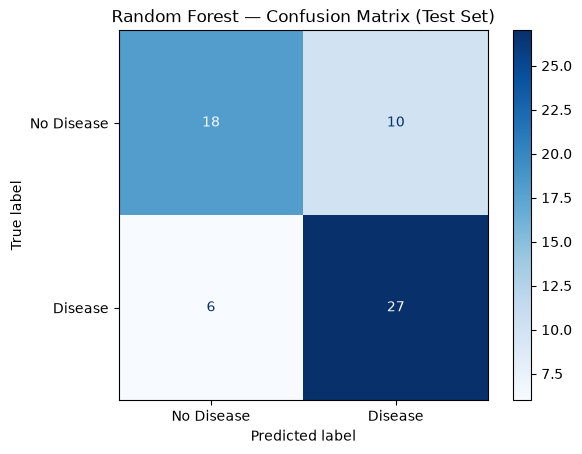

In [23]:
cm = confusion_matrix(y_test, y_test_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Disease", "Disease"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Random Forest — Confusion Matrix (Test Set)")
plt.show()


### 7.3 Feature Importance

Random Forests provide a natural measure of feature importance, based on how much each feature reduces impurity across all trees on average. This helps identify which clinical measurements are most predictive of heart disease.


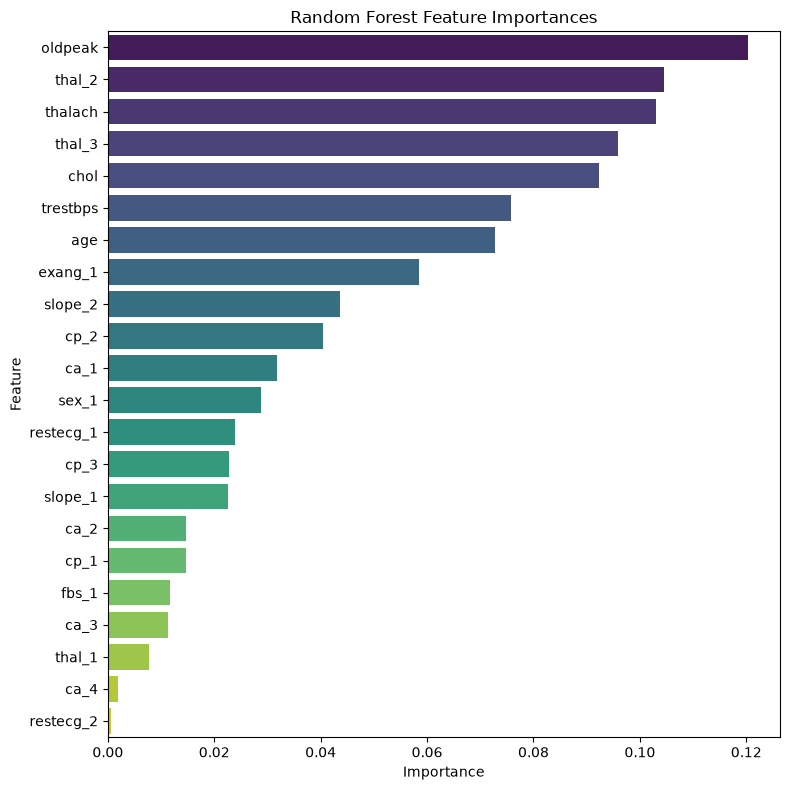

oldpeak     0.120320
thal_2      0.104619
thalach     0.103076
thal_3      0.095976
chol        0.092393
trestbps    0.075855
age         0.072806
exang_1     0.058463
slope_2     0.043648
cp_2        0.040505
dtype: float64

In [24]:
importances = pd.Series(rf_model.feature_importances_, index=X_encoded.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(8, 8))
sns.barplot(x=importances.values, y=importances.index, hue=importances.index, palette="viridis", legend=False)
plt.title("Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

importances.head(10)


### 7.4 Model Comparison

Finally, we compare all three models — the unrestricted decision tree, the controlled decision tree, and the random forest — on training and testing accuracy to see which generalizes best.


In [25]:

results = pd.DataFrame({
    "Model": ["Unrestricted Decision Tree", "Controlled Decision Tree", "Random Forest"],
    "Train Accuracy": [train_acc, train_acc_ctrl, train_acc_rf],
    "Test Accuracy": [test_acc, test_acc_ctrl, test_acc_rf],
    "Test Precision": [
        precision_score(y_test, y_test_pred_unrestricted),
        precision_score(y_test, y_test_pred_controlled),
        precision_score(y_test, y_test_pred_rf)
    ],
    "Test Recall": [
        recall_score(y_test, y_test_pred_unrestricted),
        recall_score(y_test, y_test_pred_controlled),
        recall_score(y_test, y_test_pred_rf)
    ],
    "Test F1-score": [
        f1_score(y_test, y_test_pred_unrestricted),
        f1_score(y_test, y_test_pred_controlled),
        f1_score(y_test, y_test_pred_rf)
    ]
})
results


,Model,Train Accuracy,Test Accuracy,Test Precision,Test Recall,Test F1-score
0,Unrestricted Decision Tree,1.000000,0.770492,0.756757,0.848485,0.800000
1,Controlled Decision Tree,0.904564,0.721311,0.722222,0.787879,0.753623
2,Random Forest,1.000000,0.737705,0.729730,0.818182,0.771429
